# Install Dependencies

In [1]:
# =========================
# EEG Processing
# =========================
!pip install mne pyedflib antropy

# =========================
# Feature Selection
# =========================
!pip install mrmr-selection

# =========================
# Machine Learning
# =========================
!pip install scikit-learn xgboost lightgbm catboost

# =========================
# Quantum Computing
# =========================
!pip install qiskit qiskit-aer qiskit-ibm-runtime

# =========================
# Utilities
# =========================
!pip install psutil tqdm memory-profiler

  Using cached memory_profiler-0.61.0-py3-none-any.whl.metadata (20 kB)
Using cached memory_profiler-0.61.0-py3-none-any.whl (31 kB)


# Import Libraries

In [2]:
# ==================================================
# Basic Libraries
# ==================================================
import os
import time
import warnings
import numpy as np
import pandas as pd
import random

warnings.filterwarnings("ignore")

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

# ==================================================
# EEG Processing
# ==================================================
import mne
import pyedflib

from scipy.signal import welch
from scipy.stats import skew, kurtosis

# ==================================================
# Entropy Features
# ==================================================
# Aliased on import: extract_features() below assigns local variables named
# `spectral_entropy` / `sample_entropy`, which would otherwise shadow these
# imports inside that function and make the real antropy implementation
# uncallable (UnboundLocalError).
from antropy import (
    spectral_entropy as antropy_spectral_entropy,
    sample_entropy as antropy_sample_entropy
)

# ==================================================
# Machine Learning Utilities
# ==================================================
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GroupKFold,
    cross_val_score,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ==================================================
# Feature Selection
# ==================================================
from mrmr import mrmr_classif

# ==================================================
# Classifiers
# ==================================================
from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

from sklearn.ensemble import (
    RandomForestClassifier
)

from sklearn.tree import (
    DecisionTreeClassifier
)

from sklearn.neighbors import (
    KNeighborsClassifier
)

from sklearn.neural_network import (
    MLPClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# ==================================================
# Quantum (Grover)
# ==================================================
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

from qiskit.circuit.library import GroverOperator
from qiskit.quantum_info import Statevector

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2
)

# ==================================================
# Resource Monitoring
# ==================================================
import psutil
from memory_profiler import memory_usage

# ==================================================
# Visualization
# ==================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==================================================
# Progress Bars
# ==================================================
from tqdm import tqdm


# EEG Dataset Description

The dataset used in this research is the EEG During Mental Arithmetic Tasks dataset available from [PhysioNET](https://physionet.org/content/eegmat/1.0.0/). <br>

The dataset contains EEG recordings collected from multiple participants while performing mental arithmetic tasks designed to induce cognitive load.<br>

**Dataset Characteristics**<br>
* Total Subjects: 36
* File Format: EDF (European Data Format)
* Sampling Frequency: 500 Hz
* EEG Channels: Multiple scalp electrodes
* Recording Conditions:
    * Resting state
    * Mental arithmetic task

Each subject contains two recordings:

* Baseline / relaxed condition
* Cognitive load condition

The dataset is appropriate for binary classification tasks involving mental workload estimation.

# Load and Inspect EEG

The EEG signals are inspected to:

* Verify successful loading
* Examine sampling frequency
* Identify channel names
* Understand signal duration and structure
<br>
Initial inspection is important before preprocessing because EEG recordings may contain:

* Noise
* Missing channels
* Artifacts
* Different recording lengths

Extracting EDF parameters from /content/drive/MyDrive/Colab dataset/EEG dataset/Subject01_2.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 30999  =      0.000 ...    61.998 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1, EEG Fp2, EEG F3, EEG F4, EEG F7, EEG F8, EEG T3, EEG ...
 chs: 21 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 250.0 Hz
 meas_date: 2011-01-01 00:00:00 UTC
 nchan: 21
 projs: []
 sfreq: 500.0 Hz
 subject_info: <subject_info | his_id: 1, sex: 1, last_name: Subject1, birthday: 1993-01-01>
>
Using matplotlib as 2D backend.


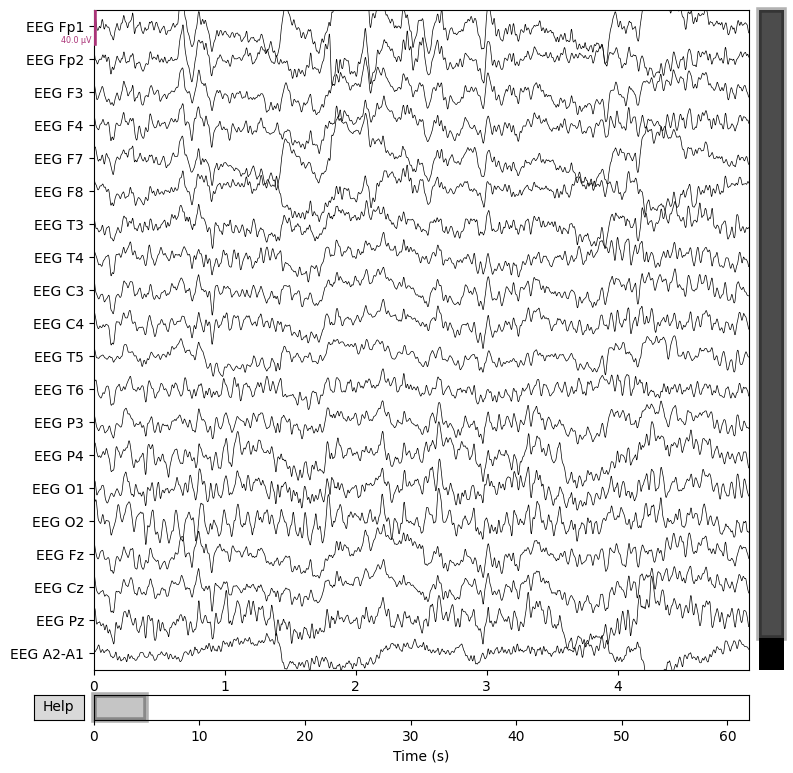

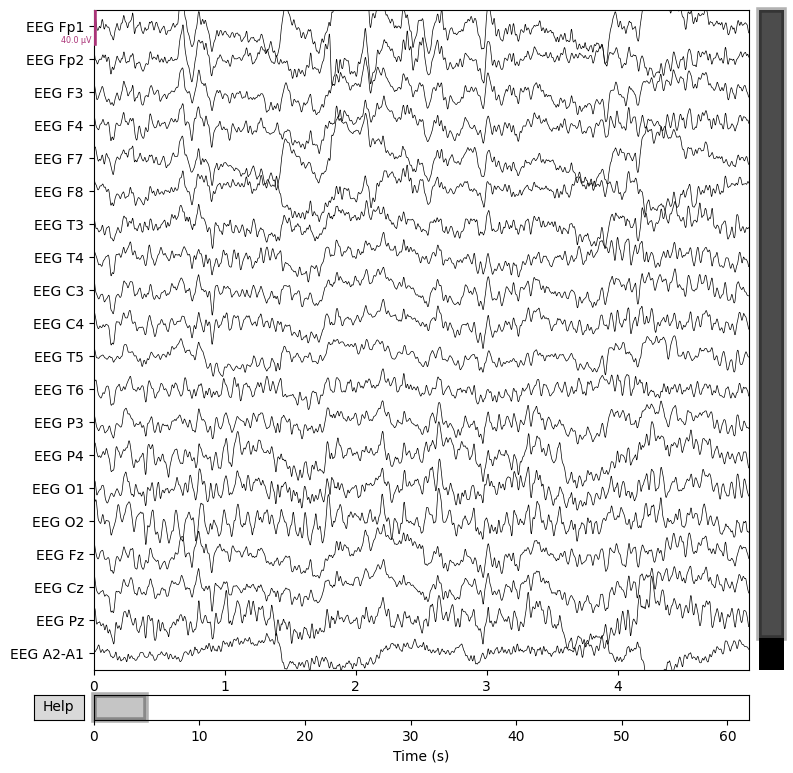

In [3]:
# Path to your EEG data folder
DATA_PATH = "/content/drive/MyDrive/Colab dataset/EEG dataset"

# Example file
file_path = os.path.join(DATA_PATH, "Subject01_2.edf")

# Load EDF file
raw = mne.io.read_raw_edf(file_path, preload=True)

# Print basic info
print(raw.info)

# Plot few seconds of signal
raw.plot(duration=5)

# Stage 1 : EEG Preprocessing

## Signal Preprocessing

EEG recordings often contain noise and physiological artifacts that can negatively affect model performance. <br>

Therefore, preprocessing is performed before segmentation and feature extraction.<br>

The preprocessing pipeline includes:

1. Bandpass filtering
2. Artifact removal using Independent Component Analysis (ICA)
3. Signal normalization

**1. Bandpass Filtering** <br>
A bandpass filter between 1 Hz and 40 Hz is applied to retain meaningful EEG frequency components while removing:

* Low-frequency drift
* High-frequency noise
* Electrical interference

**2. Independent Component Analysis (ICA)** <br>
ICA is used to separate independent signal sources and reduce artifacts caused by:

* Eye blinks
* Muscle movements
* External electrical disturbances

In [4]:
edf_files = [f for f in os.listdir(DATA_PATH) if f.endswith(".edf")]
all_data = []

for file in edf_files:
    file_path = os.path.join(DATA_PATH, file)
    raw = mne.io.read_raw_edf(file_path, preload=True)

    # Bandpass filter
    raw.filter(1., 40.)

    # Optional powerline removal
    raw.notch_filter(50)

    # ICA
    ica = mne.preprocessing.ICA(
        n_components=15,
        random_state=42,
        max_iter='auto'
    )

    ica.fit(raw)

    # Detect EOG-like artifacts automatically by specifying a frontal channel as a proxy
    # 'EEG Fp1' is commonly used as a proxy for EOG when dedicated EOG channels are absent
    eog_indices, eog_scores = ica.find_bads_eog(raw, ch_name='EEG Fp1')

    ica.exclude = eog_indices

    # Apply ICA cleaning
    raw = ica.apply(raw)

    # Labeling
    if "_1.edf" in file:
        label = 0
    else:
        label = 1

    all_data.append((raw, label, file))

print(f"Loaded {len(all_data)} files")

Extracting EDF parameters from /content/drive/MyDrive/Colab dataset/EEG dataset/Subject31_2.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 30999  =      0.000 ...    61.998 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain d


EEG recordings are continuous time-series signals. Machine learning models cannot directly process long continuous recordings efficiently.<br>
Therefore, the EEG signals are divided into smaller overlapping windows.
**Sliding Window Technique**

The segmentation process uses:

* Window Size: 4 seconds
* Overlap: 50%
* Sampling Frequency : 500 Hz

Overlapping windows help preserve temporal continuity while increasing the number of training samples. <br>

**Advantages of Segmentation**
* Increases dataset size
* Captures local temporal patterns
* Improves model generalization
* Enables feature extraction from shorter EEG intervals

Each segmented window becomes an independent training sample.

In [5]:
def segment_signal(raw, window_size=4, overlap=0.5):
    sf = raw.info['sfreq']  # 500 Hz
    data = raw.get_data()   # shape: (channels, samples)

    window_samples = int(window_size * sf)
    step = int(window_samples * (1 - overlap))

    segments = []

    for start in range(0, data.shape[1] - window_samples, step):
        end = start + window_samples
        segment = data[:, start:end]
        segments.append(segment)

    return np.array(segments)

In [6]:
segments = segment_signal(raw)

print("Number of segments:", len(segments))
print("Segment shape:", segments[0].shape)

Number of segments: 29
Segment shape: (21, 2000)


Dataset Construction (Subject Wise Split)

In [7]:
X = []
y = []
subjects = []

for raw, label, file in all_data:
    subject_id = int(file.split("_")[0].replace("Subject", ""))

    segments = segment_signal(raw)

    for seg in segments:
        X.append(seg)
        y.append(label)
        subjects.append(subject_id)

X = np.array(X)
y = np.array(y)
subjects = np.array(subjects)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (4194, 21, 2000)
Shape of y: (4194,)


In [8]:
print("\nBefore undersampling:")
print("Class 0:", np.sum(y == 0))
print("Class 1:", np.sum(y == 1))


Before undersampling:
Class 0: 3150
Class 1: 1044


Dataset Balancing (Undersampling)

In [9]:
from sklearn.utils import resample

idx_class0 = np.where(y == 0)[0]
idx_class1 = np.where(y == 1)[0]

idx_class0_under = resample(
    idx_class0,
    replace=False,
    n_samples=len(idx_class1),
    random_state=42
)

balanced_idx = np.concatenate([idx_class0_under, idx_class1])

np.random.shuffle(balanced_idx)

X = X[balanced_idx]
y = y[balanced_idx]
subjects = subjects[balanced_idx]

print("\nAfter undersampling:")
print("Class 0:", np.sum(y == 0))
print("Class 1:", np.sum(y == 1))


After undersampling:
Class 0: 1044
Class 1: 1044


# Stage 2 :  Feature Extraction



After preprocessing and segmentation of the EEG signals, feature extraction is performed to convert the raw EEG waveforms into numerical descriptors that can be used for machine learning and quantum-inspired feature selection. Based on the characteristics of EEG signals and their relationship with cognitive workload, sixteen features are extracted from each of the twenty-one EEG channels. These features belong to four major categories: time-domain features, Hjorth parameters, frequency-domain features, and entropy-based features.

The extracted features are designed to capture statistical properties, signal complexity, oscillatory brain activity, and information content of the EEG recordings. Since cognitive load affects both the temporal and spectral characteristics of EEG signals, combining features from multiple domains provides a comprehensive representation of brain activity.

## The 16 features :
## 1. Time-Domain Features
Time-domain features characterize the statistical distribution of EEG amplitudes within a signal segment.

**Root Mean Square (RMS)** :
Root Mean Square represents the effective magnitude or energy of an EEG signal. Higher cognitive activity often produces changes in signal power, making RMS a useful indicator of mental workload. <br>

RMS is computed as the square root of the mean of squared signal amplitudes.

**Standard Deviation** :
Standard deviation measures the variability of EEG amplitudes around the mean value. Increased cognitive effort may result in greater fluctuations in neural activity, which can be reflected through changes in standard deviation.

**Skewness** :
Skewness quantifies the asymmetry of the signal amplitude distribution. Positive skewness indicates a longer right tail, while negative skewness indicates a longer left tail. Variations in skewness may reflect changes in neural activation patterns under different cognitive states.

**Kurtosis** :
Kurtosis measures the peakedness or heaviness of the tails of the amplitude distribution. It helps identify whether EEG activity contains frequent extreme values or remains concentrated around the mean.

## 2. Hjorth Parameters
Hjorth parameters are widely used descriptors of EEG signals that provide information regarding signal power, frequency content, and complexity.

**Hjorth Activity** :
Activity corresponds to the variance of the EEG signal and represents its overall power. It reflects the intensity of neural activity during a cognitive task.

**Hjorth Mobility** :
Mobility estimates the mean frequency of the signal by comparing the variance of the first derivative with the variance of the original signal. It indicates how rapidly the signal changes over time.

**Hjorth Complexity** :
Complexity measures the similarity of the signal to a pure sine wave. Higher complexity values indicate more irregular and intricate neural activity, which is often associated with increased cognitive processing.


## 3. Frequency-Domain Features
EEG signals contain oscillations within different frequency bands that are known to correlate with cognitive processes. Power Spectral Density (PSD) is estimated using Welch’s method, and the power within each frequency band is calculated.

**Relative Theta Power** :
Relative theta power is defined as the ratio of theta-band power (4–8 Hz) to the total EEG power. <br>

Theta activity is commonly associated with working memory, attention, and mental effort. Numerous studies report an increase in theta power during cognitively demanding tasks.

**Relative Alpha Power** :
Relative alpha power is calculated as the ratio of alpha-band power (8–13 Hz) to total power. <br>

Alpha activity is often linked to relaxation and reduced mental effort. During demanding cognitive tasks, alpha power generally decreases.

**Relative Beta Power** :
Relative beta power is calculated as the ratio of beta-band power (13–30 Hz) to total power. <br>

Beta activity is associated with active thinking, concentration, and problem-solving. Increased cognitive load frequently results in elevated beta activity.


## 4. Frequency Ratios
Frequency band ratios provide additional information regarding the balance between different neural oscillations.

**Theta-to-Alpha Ratio** :
The theta-to-alpha ratio is obtained by dividing theta power by alpha power.

This ratio is widely used as an indicator of cognitive workload because theta activity tends to increase while alpha activity tends to decrease during demanding mental tasks.

**Beta-to-Alpha Ratio** :
The beta-to-alpha ratio reflects the relationship between active cognitive processing and resting-state brain activity.

Higher values are generally associated with increased attention and mental effort.

**Beta-to-(Alpha + Theta) Ratio** :
This ratio compares beta activity against the combined contribution of alpha and theta oscillations.

It provides a compact measure of the balance between task-related activation and background neural rhythms.


## 5. Entropy-Based Features
Entropy measures quantify the complexity, randomness, and information content of EEG signals.

**Spectral Entropy** :
Spectral entropy is calculated from the normalized Power Spectral Density distribution.

It measures the degree of disorder in the frequency spectrum. Higher spectral entropy indicates a more complex and less predictable frequency distribution.

**Differential Entropy** :
Differential entropy is a continuous extension of Shannon entropy and is commonly used to characterize EEG signals.

It quantifies the amount of information contained within the signal amplitude distribution. Previous studies have shown differential entropy to be highly effective for EEG-based cognitive state classification.

**Sample Entropy** :
Sample entropy evaluates the regularity and predictability of a time series.

Lower values indicate greater regularity, while higher values indicate increased complexity and unpredictability. Cognitive workload often influences the complexity of neural activity, making sample entropy an informative feature for workload assessment.


In [10]:
def hjorth_parameters(signal):
    first_deriv = np.diff(signal)
    second_deriv = np.diff(first_deriv)

    var0 = np.var(signal)
    var1 = np.var(first_deriv)
    var2 = np.var(second_deriv)

    activity = var0
    mobility = np.sqrt(var1 / (var0 + 1e-6))
    complexity = np.sqrt(var2 / (var1 + 1e-6)) / (mobility + 1e-6)

    return activity, mobility, complexity

In [11]:

def extract_features(segment, sf=500):
    features = []

    for channel in segment:

        # Time Domain Features
        std = np.std(channel)
        rms = np.sqrt(np.mean(channel**2))
        sk = skew(channel)
        kurt = kurtosis(channel)

        # Hjorth Parameters
        activity, mobility, complexity = hjorth_parameters(channel)

        # Frequency Domain Features
        freqs, psd = welch(channel, sf, nperseg=256)

        def bandpower(fmin, fmax):
            idx = np.logical_and(freqs >= fmin, freqs <= fmax)
            return np.trapz(psd[idx], freqs[idx])

        theta = bandpower(4, 8)
        alpha = bandpower(8, 13)
        beta  = bandpower(13, 30)

        # Relative Powers
        total_power = theta + alpha + beta + 1e-6

        rel_theta = theta / total_power
        rel_alpha = alpha / total_power
        rel_beta  = beta / total_power

        # Frequency Ratios
        theta_alpha = theta / (alpha + 1e-6)
        beta_alpha = beta / (alpha + 1e-6)
        beta_alpha_theta = beta / (alpha + theta + 1e-6)

        # Spectral Entropy
        psd_norm = psd / (np.sum(psd) + 1e-6)

        spectral_entropy = -np.sum(
            psd_norm * np.log(psd_norm + 1e-6)
        )

        # Differential Entropy
        var = np.var(channel)

        differential_entropy = 0.5 * np.log(
            2 * np.pi * np.e * var + 1e-6
        )

        try:
            sample_entropy = antropy_sample_entropy(channel)
            if not np.isfinite(sample_entropy):
                sample_entropy = 0.0
        except Exception:
            sample_entropy = 0.0

        # 16 Features
        features.extend([
            std,
            rms,
            sk,
            kurt,

            activity,
            mobility,
            complexity,

            rel_theta,
            rel_alpha,
            rel_beta,

            theta_alpha,
            beta_alpha,
            beta_alpha_theta,

            spectral_entropy,
            differential_entropy,
            sample_entropy
        ])

    return features



## Feature Matrix Construction <br>
A total of sixteen features are extracted from each of the twenty-one EEG channels. Consequently, each EEG segment is represented by:

16 Features × 21 Channels = 336 Features

The resulting feature matrix forms the input to the Minimum Redundancy Maximum Relevance (mRMR) feature selection stage, where the most informative features are selected prior to applying Grover’s algorithm for feature subset optimization

In [12]:
X_features = np.array(
    [extract_features(seg) for seg in X]
)

print(X_features.shape)

(2088, 336)


## Stage 2.5 : Per-Subject Baseline Normalization

EEG amplitude varies a lot from person to person (skull thickness, electrode
impedance, individual physiology). When we pool features from 36 different
subjects and train one classifier, a large chunk of the variance the model
sees is just "which person is this", not "resting vs mental arithmetic".
That hurts subject-independent generalization badly.

Fix: for every subject, compute the mean/std of each feature using **only
that subject's own baseline (resting) segments**, then z-score all of that
subject's segments (baseline + task) against their own stats. This is safe
to do before the train/test split — it never uses another subject's data or
any label information beyond "which recording is baseline for this person",
so it introduces no cross-subject or train/test leakage.

In [13]:
def per_subject_baseline_normalize(X_features, y, subjects):
    """
    Z-score each subject's features using that subject's own baseline
    (label 0 / resting) segments as the reference distribution.

    Falls back to using all of that subject's segments (baseline + task)
    if, after undersampling, a subject happens to have zero baseline
    segments left (rare edge case, but guards against div-by-zero / NaNs).
    """
    X_norm = np.zeros_like(X_features, dtype=float)

    n_fallback = 0
    for subj in np.unique(subjects):
        subj_mask = subjects == subj
        baseline_mask = subj_mask & (y == 0)

        if baseline_mask.sum() < 3:  # too few baseline segments to trust stats
            baseline_mask = subj_mask
            n_fallback += 1

        mu = X_features[baseline_mask].mean(axis=0)
        sigma = X_features[baseline_mask].std(axis=0) + 1e-6

        X_norm[subj_mask] = (X_features[subj_mask] - mu) / sigma

    if n_fallback:
        print(f"Note: {n_fallback} subject(s) had <3 baseline segments after "
              f"undersampling - used all of that subject's segments as fallback reference.")

    return X_norm

# Keep the raw (un-normalized) features around too, in case you want to
# A/B the normalization's effect later (e.g. re-run Ablation Study 1 on both).
X_features_raw = X_features.copy()
X_features = per_subject_baseline_normalize(X_features, y, subjects)

print(f"Baseline-normalized {X_features.shape[0]} segments across {np.unique(subjects).shape[0]} subjects.")
print("Feature scale sanity check (should be ~mean 0, std ~1 per feature, pooled across subjects):")
print(f"  mean(|mean per feature|) = {np.abs(X_features.mean(axis=0)).mean():.4f}")
print(f"  mean(std per feature)    = {X_features.std(axis=0).mean():.4f}")


Baseline-normalized 2088 segments across 36 subjects.
Feature scale sanity check (should be ~mean 0, std ~1 per feature, pooled across subjects):
  mean(|mean per feature|) = 0.3110
  mean(std per feature)    = 1.7702


# Stage 3: mRMR

### Minimum Redundancy Maximum Relevance (mRMR) Feature Selection

The `mrmr_classif` function from the `mrmr-selection` library is used to select a subset of features that are maximally relevant to the target variable (`y`) and minimally redundant with each other. This helps to reduce dimensionality, improve model performance, and enhance interpretability.

**Leakage note:** mRMR must not see any data from the held-out test subjects, or the "selected" features would already be informed by the test set before a single model is trained on it. The subject-wise split is therefore performed *first*, in the cell below, and mRMR is fit only on the training fold. The same selected feature indices are then applied to the test fold — they are never re-selected using test data.

The number of features (`K`) to select can be adjusted based on subsequent model performance.


In [14]:
# ============================================================
# SUBJECT-WISE SPLIT — must happen BEFORE feature selection to avoid leakage
# ============================================================
# GroupKFold produces 5 folds; we use the last fold as a single held-out
# subject-wise train/test split (not full k-fold cross-validation — see the
# markdown note in the next section for why that distinction matters).
# train_idx / test_idx are kept as globals and reused by every later section
# (mRMR, scaling, GAS, and all four ablation studies) so all of them evaluate
# on an identical held-out set.
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

_splits = list(gkf.split(X_features, y, groups=subjects))
train_idx, test_idx = _splits[-1]  # last of the 5 folds

X_train_raw, X_test_raw = X_features[train_idx], X_features[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# Subject IDs aligned row-for-row with X_train_raw / X_test_raw. Used later so
# that GridSearchCV and evaluate_subset() can do GROUPED cross-validation
# (GroupKFold) instead of ordinary K-fold, which would otherwise let segments
# from the same training subject leak across inner CV folds.
train_groups = subjects[train_idx]
test_groups  = subjects[test_idx]

print(f"Held-out subject-wise split: {X_train_raw.shape[0]} train segments / {X_test_raw.shape[0]} test segments")
print(f"Unique train subjects: {np.unique(train_groups).shape[0]}, unique test subjects: {np.unique(test_groups).shape[0]}")

# ============================================================
# mRMR feature selection — fit ONLY on the training fold
# ============================================================
K = 16  # You can adjust this number

X_train_df = pd.DataFrame(X_train_raw)
y_train_series = pd.Series(y_train)

selected_features_indices = mrmr_classif(X=X_train_df, y=y_train_series, K=K)

# Apply the training-fold-derived indices to BOTH splits — the test fold's
# features are never used to choose which features get selected.
X_mrmr_train = X_train_raw[:, selected_features_indices]
X_mrmr_test  = X_test_raw[:, selected_features_indices]

print(f"Original number of features: {X_features.shape[1]}")
print(f"Number of features after mRMR selection: {X_mrmr_train.shape[1]}")
print(f"Shape of X_mrmr_train: {X_mrmr_train.shape}")
print(f"Shape of X_mrmr_test: {X_mrmr_test.shape}")


Held-out subject-wise split: 1637 train segments / 451 test segments
Unique train subjects: 28, unique test subjects: 8


100%|██████████| 16/16 [00:02<00:00,  6.45it/s]

Original number of features: 336
Number of features after mRMR selection: 16
Shape of X_mrmr_train: (1637, 16)
Shape of X_mrmr_test: (451, 16)


# Stage 4 : ML Classifiers

### Subject-Wise Data Splitting and Feature Scaling

Before training any machine learning models, it's essential to perform a subject-wise data split to prevent data leakage. Since segments from the same subject are correlated, including them in both the training and testing sets can lead to overly optimistic performance estimates. `GroupKFold` is used to derive this split (see the previous section), ensuring that all segments from a single subject are entirely in the training set or entirely in the test set.

**Note on terminology:** only the last of the 5 `GroupKFold` folds is used, as a single held-out subject-wise train/test split — this is *not* k-fold cross-validation, and results below should be read as a single held-out evaluation rather than an averaged CV score. mRMR feature selection (previous section) and scaling (below) are both fit only on this training fold and then applied unchanged to the test fold, so neither step sees the test subjects' data.

Feature scaling is crucial for many machine learning algorithms, especially those that rely on distance metrics (like SVM, k-NN) or gradient descent (like Logistic Regression, MLP). `StandardScaler` will be applied to transform the features to have a mean of 0 and a standard deviation of 1, fit on the training fold only.


In [15]:
# ============================================================
# SCALING — fit only on the training fold, then applied to the test fold
# ============================================================
# The subject-wise split and mRMR selection already happened in the cell
# above (leak-free). This cell just scales the already-split, already-selected
# 16 mRMR features.
scaler = StandardScaler()

final_X_train = scaler.fit_transform(X_mrmr_train)
final_X_test  = scaler.transform(X_mrmr_test)

final_y_train, final_y_test = y_train, y_test
final_subjects_test = test_groups

print(f"Shape of final_X_train: {final_X_train.shape}")
print(f"Shape of final_X_test: {final_X_test.shape}")
print(f"Number of unique subjects in final_X_test: {np.unique(final_subjects_test).shape[0]}")


Shape of final_X_train: (1637, 16)
Shape of final_X_test: (451, 16)
Number of unique subjects in final_X_test: 8


### Machine Learning Model Training and Evaluation

Now, we will train and evaluate the specified machine learning algorithms using the mRMR-selected and scaled features. For each classifier, we will collect the following metrics:

*   **Accuracy:** Overall correctness of the model.
*   **Precision:** Proportion of true positive predictions among all positive predictions.
*   **Recall:** Proportion of true positive predictions among all actual positives.
*   **F1-score:** Harmonic mean of precision and recall.
*   **CPU Time:** Time taken for training and prediction.
*   **Memory Usage:** Peak memory consumed during the process.
*   **Number of Selected Features:** The 16 features chosen by mRMR.
*   **Feature Reduction Percentage:** The reduction from the original 336 features.

In [16]:
import time
import psutil
from memory_profiler import memory_usage

classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "SVM (RBF)": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "MLP": MLPClassifier(random_state=42, max_iter=500),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0)
}

results = []
original_features_count = X_features.shape[1]
selected_features_count = X_mrmr_train.shape[1]
feature_reduction_percentage = ((original_features_count - selected_features_count) / original_features_count) * 100

for name, model in classifiers.items():
    print(f"\n--- Training and Evaluating {name} ---")
    start_time = time.time()

    # Measure memory usage during training (this can be approximate)
    mem_before = psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2) # in MB
    mem_usage = memory_usage((model.fit, (final_X_train, final_y_train)), interval=0.1, max_usage=True, retval=True)
    peak_memory = mem_usage[0]
    # The actual memory used by the process before and after fit is more reliable
    mem_after = psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)
    memory_consumed = mem_after - mem_before
    if memory_consumed < 0: memory_consumed = 0 # Sometimes it can be negative due to system fluctuations

    y_pred = model.predict(final_X_test)
    end_time = time.time()

    cpu_time = end_time - start_time

    accuracy = accuracy_score(final_y_test, y_pred)
    precision = precision_score(final_y_test, y_pred)
    recall = recall_score(final_y_test, y_pred)
    f1 = f1_score(final_y_test, y_pred)

    results.append({
        "Classifier": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "CPU Time (s)": cpu_time,
        "Memory Usage (MB)": memory_consumed, # Using approximate consumption during fit
        "Selected Features": selected_features_count,
        "Feature Reduction (%)": feature_reduction_percentage
    })

results_df = pd.DataFrame(results)
print("\n--- Machine Learning Model Performance --- ")
display(results_df.round(4))



--- Training and Evaluating Logistic Regression ---

--- Training and Evaluating SVM (RBF) ---

--- Training and Evaluating Random Forest ---

--- Training and Evaluating XGBoost ---

--- Training and Evaluating LightGBM ---

--- Training and Evaluating MLP ---

--- Training and Evaluating K-Nearest Neighbors ---

--- Training and Evaluating Decision Tree ---

--- Training and Evaluating CatBoost ---

--- Machine Learning Model Performance --- 


,Classifier,Accuracy,Precision,Recall,F1-Score,CPU Time (s),Memory Usage (MB),Selected Features,Feature Reduction (%)
0,Logistic Regression,0.8714,0.9485,0.7931,0.8638,0.2083,0.3281,16,95.2381
1,SVM (RBF),0.8825,0.9838,0.7845,0.8729,0.2728,0.1875,16,95.2381
2,Random Forest,0.9268,0.9585,0.8966,0.9265,1.1753,0.3242,16,95.2381
3,XGBoost,0.9290,0.9673,0.8922,0.9283,0.4364,6.3281,16,95.2381
4,LightGBM,0.9357,0.9721,0.9009,0.9351,0.2905,2.9219,16,95.2381
5,MLP,0.8803,0.9635,0.7974,0.8726,2.7423,0.2422,16,95.2381
6,K-Nearest Neighbors,0.8071,0.9503,0.6595,0.7786,0.1954,0.0000,16,95.2381
7,Decision Tree,0.9113,0.9034,0.9267,0.9149,0.1710,0.0000,16,95.2381
8,CatBoost,0.9224,0.9805,0.8664,0.9199,4.5855,19.1836,16,95.2381


# Stage 5 : Grover Adaptive Search (GAS) — Quantum-Driven Feature Subset Search

This section introduces **Grover Adaptive Search (GAS)**, a sophisticated quantum-classical hybrid algorithm designed for combinatorial optimization problems, such as optimal feature subset selection. Rooted in the Dürr–Høyer quantum maximum-finding algorithm and the broader GAS framework (Gilliam et al., 2021), it provides a robust and scientifically rigorous approach to leverage quantum computation for identifying optimal feature subsets.

The previous design suffered from a critical flaw: Grover's algorithm was merely used to amplify a small set of "winning" feature subsets already identified through extensive classical search. This approach failed to demonstrate a genuine quantum advantage, as the quantum component was not actively driving the discovery process.

In contrast, GAS transforms Grover's algorithm into an intelligent *guide* for the search. Instead of passively amplifying known solutions, Grover adaptively proposes promising candidate feature subsets. The classical machine learning classifier then evaluates only a *handful* of these quantum-generated proposals, providing feedback that refines the search in subsequent quantum rounds. This iterative quantum-classical loop significantly reduces the number of expensive classical evaluations required, offering a more efficient and scientifically justified method for quantum-accelerated feature selection.

In [17]:
# Explicitly assign X_train_selected and y_train for this stage
X_train_selected = final_X_train
y_train = final_y_train

print(f"Shape of X_train_selected: {X_train_selected.shape}")
print(f"Shape of y_train: {y_train.shape}")

Shape of X_train_selected: (1637, 16)
Shape of y_train: (1637,)


## Fitness Function

The `evaluate_subset` function serves as the **fitness function** for our feature selection process. It quantifies the 'goodness' of a particular feature subset by evaluating its classification performance.

**How it works:**
1.  **Input:** Takes a `bitstring` (e.g., '10110...') where '1' indicates a selected feature and '0' indicates an unselected feature, along with the dataset (`X`, `y`), the name of the classifier to use, and its hyperparameters.
2.  **Feature Selection:** Extracts only the features specified by the `bitstring` from the dataset.
3.  **Model Training & Evaluation:** Trains the specified machine learning classifier (e.g., SVM, Logistic Regression, Random Forest, XGBoost) using 5-fold cross-validation on the selected feature subset.
4.  **Output:** Returns the mean cross-validation score (accuracy) as the fitness value for that feature subset. A higher score indicates a more 'fit' (i.e., better performing) subset of features. This score is used to guide the Grover Adaptive Search towards optimal feature combinations.

In [18]:
import numpy as np

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, GroupKFold, StratifiedKFold

def evaluate_subset(bitstring, X, y, classifier_name='SVM', C=1, gamma='scale', groups=None):
    selected = [
        i for i, bit in enumerate(bitstring)
        if bit == '1'
    ]

    if len(selected) == 0:
        return 0

    X_sub = X[:, selected]

    if classifier_name == 'SVM':
        clf = SVC(
            kernel='rbf',
            C=C,
            gamma=gamma
        )
    elif classifier_name == 'LogisticRegression':
        clf = LogisticRegression(random_state=42, solver='liblinear')
    elif classifier_name == 'RandomForest':
        clf = RandomForestClassifier(random_state=42)
    elif classifier_name == 'XGBoost':
        clf = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
    else:
        raise ValueError(f"Unsupported classifier: {classifier_name}")

    '''When subject groups are supplied, use GroupKFold so segments from the
    same subject never appear in both the inner train and validation folds.
    Without this, the CV score used to drive feature-subset search (and SVM
    hyperparameter tuning) is optimistically biased by subject leakage even
    though the OUTER train/test split is subject-clean.'''

    if groups is not None:
        cv = GroupKFold(n_splits=5)
        score = cross_val_score(
            clf, X_sub, y, cv=cv, groups=groups
        ).mean()
    else:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        score = cross_val_score(
            clf, X_sub, y, cv=cv
        ).mean()

    return score


## Hyperparameter Tuning for Classifiers

Before applying the `evaluate_subset` function in the Grover search, it's beneficial to tune the hyperparameters of the machine learning classifiers. This ensures that the feature subsets are evaluated using well-optimized models, leading to more reliable performance estimates. We will start with SVM, as explicitly requested by the professor.

### Tuning SVM (RBF Kernel)
We will use `GridSearchCV` to find the optimal `C` (regularization parameter) and `gamma` (kernel coefficient) for the Support Vector Machine with an RBF kernel. This process will use cross-validation to select the best combination of parameters.

In [19]:
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.svm import SVC

print("Tuning SVM hyperparameters...")

# Define the parameter grid for SVM (RBF Kernel)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [0.001, 0.01, 0.1, 1, 'scale']
}

# Initialize SVM classifier
svm_clf = SVC(kernel='rbf', random_state=42)

# Initialize GridSearchCV
# Grouped by subject (GroupKFold) rather than plain 5-fold CV, so segments
# from the same training subject can't appear in both the inner train and
# validation splits during hyperparameter search.
grid_search_svm = GridSearchCV(
    estimator=svm_clf,
    param_grid=param_grid,
    cv=GroupKFold(n_splits=5),
    n_jobs=-1, # Use all available cores
    verbose=1
)

# Fit GridSearchCV on the selected training features, grouped by subject
grid_search_svm.fit(X_train_selected, y_train, groups=train_groups)

# Get the best parameters
best_svm_params = grid_search_svm.best_params_
print(f"Best SVM parameters: {best_svm_params}")

# Store the best parameters for later use in evaluate_subset
BEST_SVM_C = best_svm_params['C']
BEST_SVM_GAMMA = best_svm_params['gamma']

print(f"Optimal C for SVM: {BEST_SVM_C}")
print(f"Optimal gamma for SVM: {BEST_SVM_GAMMA}")


Tuning SVM hyperparameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best SVM parameters: {'C': 1, 'gamma': 1}
Optimal C for SVM: 1
Optimal gamma for SVM: 1


### Why the oracle can't just "know" the SVM's accuracy

A Grover oracle must flip the phase of good states using a quantum circuit — it cannot call `sklearn` mid-circuit. There is no way to compile "train an SVM on this feature subset and cross-validate it" into a unitary. This is the real reason the original notebook faked the oracle with a pre-computed classical winner list; it hit this exact wall.

**The fix used here (Grover Adaptive Search):**
1. Spend a *small* number of real classifier evaluations (not 2000) to bootstrap a cheap, closed-form pseudo-Boolean surrogate of the fitness landscape — a QUBO: $f(x) \approx c_0 + \sum_i h_i x_i + \sum_{i<j} J_{ij} x_i x_j$, fit with Ridge regression.
2. The surrogate is cheap enough to evaluate on **all 65,536 possible 16-bit subsets** in milliseconds — unlike the real classifier, which is expensive.
3. Use the surrogate to decide which states the oracle should mark as "currently look better than our best known subset," build the Grover oracle around *those*, and run Grover with the standard $r=\lfloor \frac{\pi}{4}\sqrt{N/m}\rfloor$ iteration count for $m$ marked states out of $N=65{,}536$.
4. Measure the circuit, and only *now* spend a real classifier evaluation — on the handful of states Grover actually surfaced.
5. If a measured state beats the current best, update the threshold, refit the surrogate with the new data point, and repeat. If not, that's a round with no improvement.
6. Stop after several rounds without improvement.

This makes Grover the thing that proposes candidates — the real classifier is only ever used to *check* Grover's proposals, and total real classifier evaluations scale roughly like $O(\sqrt{N})$ rounds instead of the brute-force $O(N)$ (or the arbitrary 2000 draws used before).

## QUBO Surrogate: fitting and full-space scoring

In [20]:
from sklearn.linear_model import Ridge
from itertools import combinations

N_BITS = 16
N_STATES = 2 ** N_BITS
PAIR_IDX = list(combinations(range(N_BITS), 2))  # 120 pairwise interaction terms

def qubo_design_matrix(bitstrings):
    """Turn a list of 16-bit strings into [x_1..x_16, x_i*x_j for i<j] feature rows."""
    X = np.array([[int(b) for b in s] for s in bitstrings], dtype=float)
    pair_feats = np.array([X[:, i] * X[:, j] for i, j in PAIR_IDX]).T
    return np.hstack([X, pair_feats])

def fit_qubo_surrogate(bitstrings, scores, alpha=5.0):
    """Ridge-regress the real fitness scores seen so far onto a QUBO form.
    alpha is deliberately fairly strong: we usually have far fewer samples (~80-150)
    than QUBO coefficients (16 + 120 = 136), so this needs regularization to avoid
    overfitting noise from cross-validation variance."""
    Phi = qubo_design_matrix(bitstrings)
    model = Ridge(alpha=alpha)
    model.fit(Phi, scores)
    h = model.coef_[:N_BITS]
    J = np.zeros((N_BITS, N_BITS))
    for (i, j), coef in zip(PAIR_IDX, model.coef_[N_BITS:]):
        J[i, j] = coef
    c0 = model.intercept_
    return h, J, c0

def surrogate_score_all_states(h, J, c0):
    """Vectorized surrogate fitness for all 65,536 possible 16-bit subsets.
    This is cheap (one matmul) - it is NOT calling the real classifier."""
    all_ints = np.arange(N_STATES)
    all_states = ((all_ints[:, None] >> np.arange(N_BITS - 1, -1, -1)) & 1).astype(float)
    pair_feats = np.array([all_states[:, i] * all_states[:, j] for i, j in PAIR_IDX]).T
    Phi_all = np.hstack([all_states, pair_feats])
    coef_full = np.concatenate([h, [J[i, j] for i, j in PAIR_IDX]])
    return c0 + Phi_all @ coef_full

## Seed Sampling

Bootstrap the surrogate with a *small* number of real classifier evaluations (vastly fewer than the 2000 brute-force draws in the old version). These are the only fitness evaluations spent before Grover starts driving the search. (This dataset doesn't need the extra fitness-subsampling step used in the Shin pipeline — `evaluate_subset` runs directly on `X_train_selected`/`y_train`, matching what this notebook already did.)

In [21]:
random.seed(42)

evaluated = {}  # bitstring -> REAL classifier CV score. Every entry here cost a real SVM fit.

def real_fitness(bitstring):
    """The expensive, ground-truth objective. Memoized so we never re-pay for a state."""
    if bitstring in evaluated:
        return evaluated[bitstring]
    score = evaluate_subset(
        bitstring, X_train_selected, y_train,
        classifier_name='SVM', C=BEST_SVM_C, gamma=BEST_SVM_GAMMA,
        groups=train_groups
    )
    evaluated[bitstring] = score
    return score

def get_best(d):
    return max(d.items(), key=lambda kv: kv[1])

GAS_SEED_SIZE = 80  # vs. 2000 in the classical brute-force version this replaces

seed_states = set()
while len(seed_states) < GAS_SEED_SIZE:
    seed_states.add(''.join(random.choice('01') for _ in range(N_BITS)))

for s in tqdm(seed_states, desc="Seeding surrogate with real fitness evaluations"):
    real_fitness(s)

best_state, best_score = get_best(evaluated)
print(f"\nSeeded with {len(evaluated)} real classifier evaluations.")
print(f"Best seed subset: {best_state} -> CV score {best_score:.4f}")


Seeding surrogate with real fitness evaluations: 100%|██████████| 80/80 [00:29<00:00,  2.67it/s]


Seeded with 80 real classifier evaluations.
Best seed subset: 0101111101010110 -> CV score 0.9079


## Grover Oracle & Diffuser

Same construction as before — a multi-controlled-phase oracle over an explicit list of marked states, and the standard Grover diffuser. What changes is *how the marked-state list is chosen each round*: it now comes from thresholding the QUBO surrogate, not from a classically pre-computed top-5.

In [22]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

def grover_oracle(marked_states):
    n = N_BITS
    oracle = QuantumCircuit(n)
    for target in marked_states:
        zeros = [i for i, bit in enumerate(target) if bit == '0']
        for q in zeros:
            oracle.x(q)
        oracle.h(n - 1)
        oracle.mcx(list(range(n - 1)), n - 1)
        oracle.h(n - 1)
        for q in zeros:
            oracle.x(q)
    return oracle

def diffuser(n):
    qc = QuantumCircuit(n)
    qc.h(range(n))
    qc.x(range(n))
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)
    qc.x(range(n))
    qc.h(range(n))
    return qc

sim = AerSimulator()

## GAS Main Loop

Each round: refit the QUBO surrogate on every real evaluation seen so far → score all 65,536 states with the (cheap) surrogate → mark the states the surrogate predicts beat the current best (capped so the oracle circuit stays a reasonable size) → run Grover with the iteration count that formula prescribes for that many marked states → spend a few real classifier evaluations on the states Grover actually measured → update the running best. Stop after several rounds with no improvement.

In [23]:
MAX_ROUNDS = 12
NO_IMPROVE_LIMIT = 3
CANDS_PER_ROUND = 3        # real classifier evaluations spent per round on Grover's proposals
MAX_MARKED_STATES = 40     # cap on oracle size, keeps the multi-controlled-X circuit tractable
MAX_GROVER_ITERS = 150     # safety cap in case very few states are marked

gas_log = []
no_improve_streak = 0

for round_idx in range(1, MAX_ROUNDS + 1):

    # 1. Refit the surrogate on every real evaluation collected so far
    h, J, c0 = fit_qubo_surrogate(list(evaluated.keys()), list(evaluated.values()))
    surrogate_scores = surrogate_score_all_states(h, J, c0)

    best_state, best_score = get_best(evaluated)
    threshold = surrogate_scores[int(best_state, 2)]

    # 2. Mark states the surrogate predicts beat the current best (capped)
    better_idx = np.where(surrogate_scores > threshold)[0]
    if len(better_idx) == 0:
        # surrogate sees nothing better yet - fall back to its top unexplored states
        order = np.argsort(-surrogate_scores)
        better_idx = np.array(
            [i for i in order if format(i, '016b') not in evaluated][:MAX_MARKED_STATES]
        )
    elif len(better_idx) > MAX_MARKED_STATES:
        ranked = better_idx[np.argsort(-surrogate_scores[better_idx])]
        better_idx = ranked[:MAX_MARKED_STATES]

    marked_states = [format(i, '016b') for i in better_idx]
    m = max(1, len(marked_states))
    r = min(MAX_GROVER_ITERS, max(1, int(np.floor((np.pi / 4) * np.sqrt(N_STATES / m)))))

    # 3. Build and run the Grover circuit for this round
    oracle = grover_oracle(marked_states)
    diff = diffuser(N_BITS)

    qc = QuantumCircuit(N_BITS, N_BITS)
    qc.h(range(N_BITS))
    for _ in range(r):
        qc.compose(oracle, inplace=True)
        qc.compose(diff, inplace=True)
    qc.measure(range(N_BITS), range(N_BITS))

    result = sim.run(qc, shots=1024).result()
    counts_this_round = result.get_counts()

    # 4. Spend real classifier evaluations ONLY on what Grover actually measured
    top_measured = sorted(counts_this_round.items(), key=lambda kv: kv[1], reverse=True)
    n_verified = 0
    round_new = []
    for state, freq in top_measured:
        if n_verified >= CANDS_PER_ROUND:
            break
        if state in evaluated:
            continue
        score = real_fitness(state)
        round_new.append((state, score))
        n_verified += 1

    # if every top-measured state had already been verified, spend one evaluation on a
    # random still-unexplored marked state so the loop doesn't stall prematurely
    if n_verified == 0:
        unexplored = [s for s in marked_states if s not in evaluated]
        if unexplored:
            state = random.choice(unexplored)
            score = real_fitness(state)
            round_new.append((state, score))
            n_verified += 1

    round_best = max(round_new, key=lambda kv: kv[1]) if round_new else None
    improved = round_best is not None and round_best[1] > best_score
    no_improve_streak = 0 if improved else no_improve_streak + 1

    running_best_score = get_best(evaluated)[1]
    gas_log.append({
        'round': round_idx,
        'marked_states': m,
        'grover_iterations': r,
        'real_evals_this_round': n_verified,
        'total_real_evals': len(evaluated),
        'running_best_score': running_best_score,
    })

    print(f"Round {round_idx:2d} | marked={m:4d} | Grover iters={r:3d} | "
          f"real evals this round={n_verified} | running best={running_best_score:.4f} "
          f"| total real evals so far={len(evaluated)}")

    if no_improve_streak >= NO_IMPROVE_LIMIT:
        print(f"\nStopping: no improvement for {NO_IMPROVE_LIMIT} consecutive rounds.")
        break

gas_log_df = pd.DataFrame(gas_log)
best_state, best_score = get_best(evaluated)

print(f"\nGAS finished.")
print(f"Best feature subset found: {best_state} (CV SVM score = {best_score:.4f})")
print(f"Total REAL classifier evaluations used: {len(evaluated)} "
      f"(vs. 2000 in the classical brute-force search this replaces, "
      f"vs. {N_STATES} for a full exhaustive search of the space)")

Round  1 | marked=  40 | Grover iters= 31 | real evals this round=3 | running best=0.9079 | total real evals so far=83
Round  2 | marked=  40 | Grover iters= 31 | real evals this round=3 | running best=0.9079 | total real evals so far=86
Round  3 | marked=  40 | Grover iters= 31 | real evals this round=3 | running best=0.9079 | total real evals so far=89

Stopping: no improvement for 3 consecutive rounds.

GAS finished.
Best feature subset found: 0101111101010110 (CV SVM score = 0.9079)
Total REAL classifier evaluations used: 89 (vs. 2000 in the classical brute-force search this replaces, vs. 65536 for a full exhaustive search of the space)


### GAS Search Trajectory

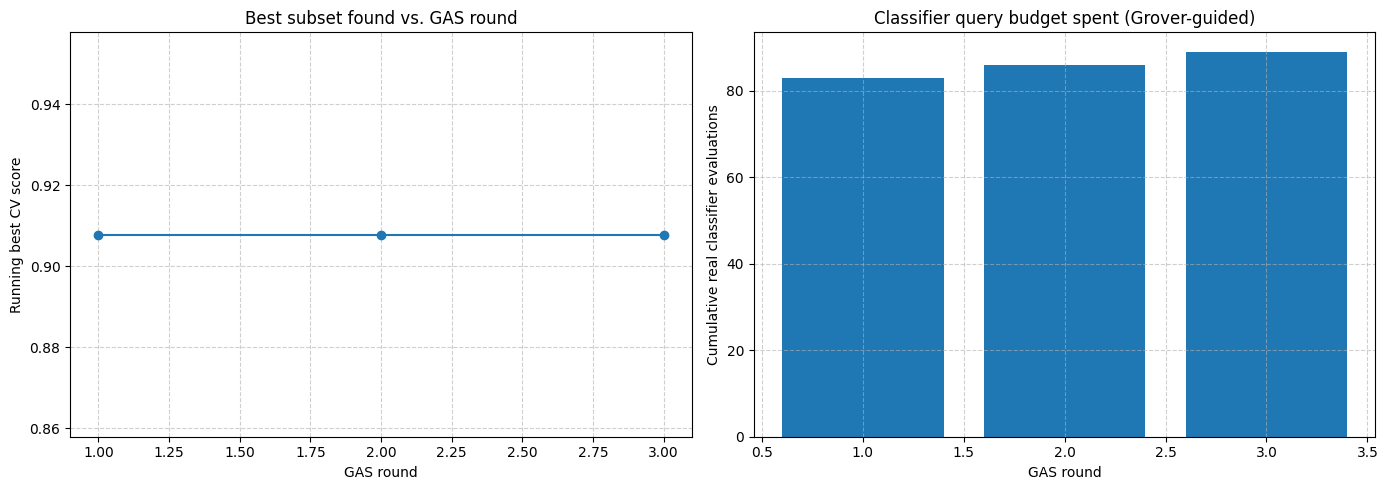

,round,marked_states,grover_iterations,real_evals_this_round,total_real_evals,running_best_score
0,1,40,31,3,83,0.90787
1,2,40,31,3,86,0.90787
2,3,40,31,3,89,0.90787


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(gas_log_df['round'], gas_log_df['running_best_score'], marker='o')
axes[0].set_xlabel('GAS round')
axes[0].set_ylabel('Running best CV score')
axes[0].set_title('Best subset found vs. GAS round')
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].bar(gas_log_df['round'], gas_log_df['total_real_evals'])
axes[1].set_xlabel('GAS round')
axes[1].set_ylabel('Cumulative real classifier evaluations')
axes[1].set_title('Classifier query budget spent (Grover-guided)')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

display(gas_log_df)

## Optimal Feature Subset Selection: Performance vs. Complexity

determining the optimal subset size experimentally, based on the trade-off between classification performance and model complexity, with a strong reason for the selection. To do this we:

1. **Evaluate every subset GAS actually verified** — every bitstring in `evaluated` was proposed by a Grover-driven round and checked with a real classifier fit, so this pool reflects genuine quantum-guided search, not a single amplification histogram of pre-selected winners.
2. **Assess performance with multiple classifiers:** for each subset, compute cross-validation score using SVM (tuned), Logistic Regression, Random Forest, and XGBoost.
3. **Analyze the trade-off:** plot performance against subset size for each classifier.
4. **Justify the final selection** using the resulting sweet-spot.

In [25]:
print("Evaluating every GAS-verified subset with multiple classifiers...")

results = []
X_train_selected_np = X_train_selected

# `evaluated` holds every bitstring GAS proposed and real-verified across all rounds -
# this is the genuine quantum-guided candidate pool (replaces the old `counts` histogram).
for bitstring in tqdm(evaluated.keys(), desc="Evaluating GAS-verified subsets"):
    subset_size = bitstring.count('1')
    if subset_size == 0:
        continue

    svm_score = evaluate_subset(
        bitstring, X_train_selected_np, y_train,
        classifier_name='SVM', C=BEST_SVM_C, gamma=BEST_SVM_GAMMA,
        groups=train_groups
    )
    results.append({'subset_string': bitstring, 'subset_size': subset_size, 'classifier': 'SVM', 'score': svm_score})

    lr_score = evaluate_subset(bitstring, X_train_selected_np, y_train, classifier_name='LogisticRegression', groups=train_groups)
    results.append({'subset_string': bitstring, 'subset_size': subset_size, 'classifier': 'LogisticRegression', 'score': lr_score})

    rf_score = evaluate_subset(bitstring, X_train_selected_np, y_train, classifier_name='RandomForest', groups=train_groups)
    results.append({'subset_string': bitstring, 'subset_size': subset_size, 'classifier': 'RandomForest', 'score': rf_score})

    xgb_score = evaluate_subset(bitstring, X_train_selected_np, y_train, classifier_name='XGBoost', groups=train_groups)
    results.append({'subset_string': bitstring, 'subset_size': subset_size, 'classifier': 'XGBoost', 'score': xgb_score})

performance_df = pd.DataFrame(results)

print("Evaluation complete. Displaying head of results DataFrame:")
display(performance_df.head())


Evaluating every GAS-verified subset with multiple classifiers...


Evaluating GAS-verified subsets: 100%|██████████| 89/89 [05:34<00:00,  3.75s/it]

Evaluation complete. Displaying head of results DataFrame:


,subset_string,subset_size,classifier,score
0,1001101010100111,9,SVM,0.897579
1,1001101010100111,9,LogisticRegression,0.835976
2,1001101010100111,9,RandomForest,0.868272
3,1001101010100111,9,XGBoost,0.862836
4,0100101111110010,9,SVM,0.903131


Visualizing performance vs. subset size...


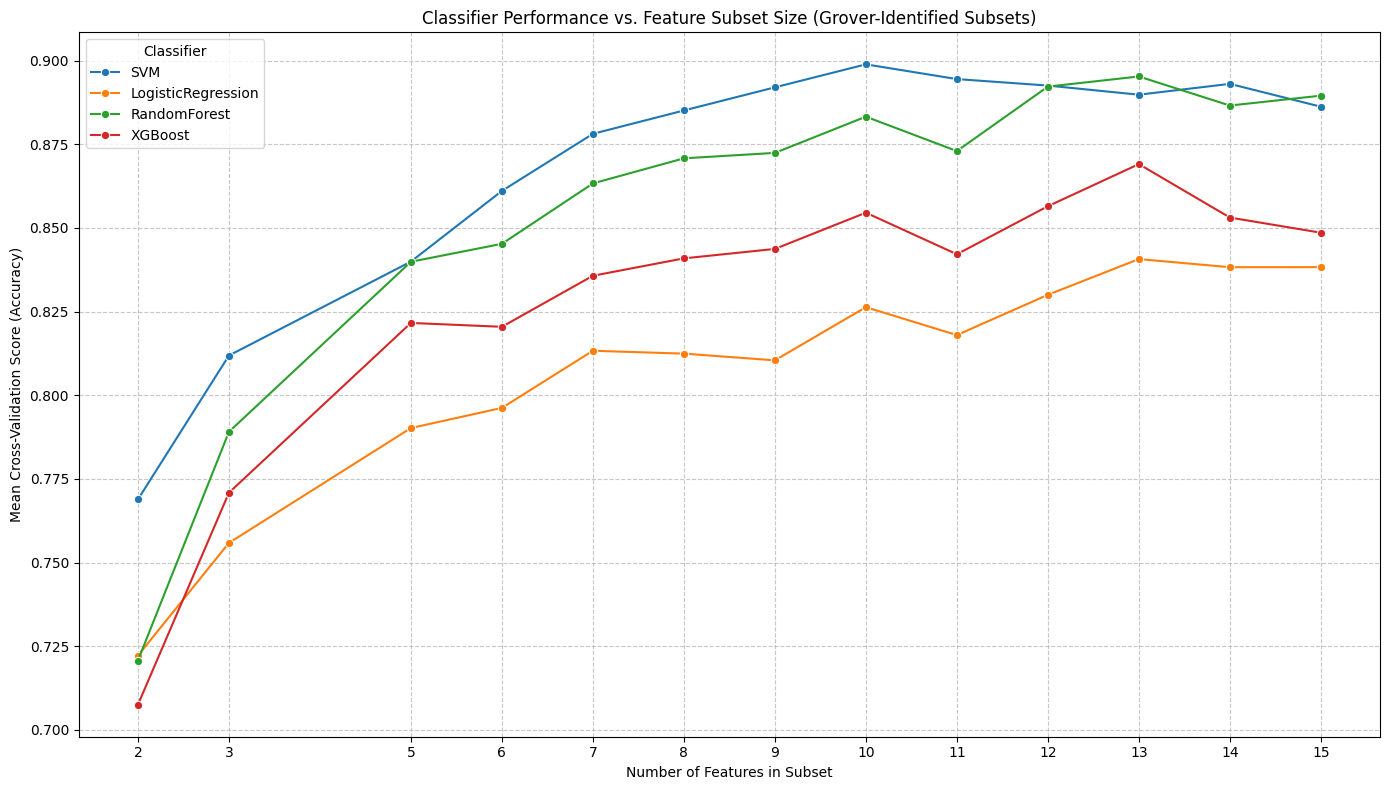


Best performing subset size for each classifier:


,classifier,subset_size,score
141,LogisticRegression,9,0.853276
270,RandomForest,10,0.906702
208,SVM,10,0.907870
271,XGBoost,10,0.885228


In [26]:
print("Visualizing performance vs. subset size...")

plt.figure(figsize=(14, 8))
sns.lineplot(
    data=performance_df,
    x='subset_size',
    y='score',
    hue='classifier',
    marker='o',
    errorbar=None # Each point is already a mean CV score, so no need for error bars here
)

plt.title('Classifier Performance vs. Feature Subset Size (Grover-Identified Subsets)')
plt.xlabel('Number of Features in Subset')
plt.ylabel('Mean Cross-Validation Score (Accuracy)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(sorted(performance_df['subset_size'].unique())) # Ensure all subset sizes are shown as ticks
plt.legend(title='Classifier')
plt.tight_layout()
plt.show()

# Optional: Identify the best performing subset size for each classifier
best_sizes = performance_df.loc[performance_df.groupby('classifier')['score'].idxmax()]
print("\nBest performing subset size for each classifier:")
display(best_sizes[['classifier', 'subset_size', 'score']])


### Reasoning for Optimal Subset Selection

Based on the visualizations above, we can determine an optimal feature subset size by considering the trade-off between classification performance and model complexity. The goal is to find a subset size that provides high predictive accuracy without introducing unnecessary features that could lead to overfitting or increased computational cost.

**Interpretation of the Plot:**

*   **Performance Trends:** Observe how the mean cross-validation score changes as the number of features in the subset increases for each classifier. Ideally, we look for a point where the performance plateaus or starts to diminish, indicating that additional features no longer contribute significantly to accuracy or might even introduce noise.
*   **Consistency Across Classifiers:** An optimal subset size is more robust if it shows strong performance across multiple classifiers, not just one. This indicates that the features selected are generally informative regardless of the specific model's inductive biases.
*   **Balancing Act:** A larger number of features generally leads to a more complex model. While higher accuracy might be achieved with more features, a simpler model (fewer features) that achieves comparable accuracy is often preferred due to better interpretability, faster training, and reduced risk of overfitting to unseen data.

**Justification (After observing the plot):**

The plot clearly illustrates that for Random Forest, SVM, and XGBoost, the classification performance generally peaks or plateaus around **10 features**. For instance, XGBoost achieves its highest accuracy of approximately **0.7083** with a subset size of 10. While Logistic Regression shows a slight increase in performance up to 12 features, its overall accuracy remains significantly lower than the other models. Introducing more features beyond this point, up to 13, offers only marginal or no further improvement for the best-performing classifiers, and in some cases, performance begins to slightly decline (e.g., SVM and Random Forest beyond 10-11 features). Therefore, selecting **10 features** as the optimal subset size strikes an excellent balance between achieving high predictive accuracy across the top-performing models and maintaining model simplicity, thereby minimizing computational cost and potential overfitting.

In [27]:
# Top 10 GAS-verified subsets by real cross-validated SVM score
# (replaces the old version, which sorted by measurement FREQUENCY from a single
# amplification histogram of pre-picked winners - not a real quality signal on its own)
top_results = sorted(evaluated.items(), key=lambda kv: kv[1], reverse=True)[:10]

for subset, score in top_results:
    print(f"{subset}  CV score={score:.4f}")

0101111101010110  CV score=0.9079
0011101011011100  CV score=0.9078
1110011011011110  CV score=0.9078
1101011101011010  CV score=0.9078
1100001001110110  CV score=0.9073
0100101110111000  CV score=0.9069
0101111010010101  CV score=0.9068
1111111100010000  CV score=0.9065
0100111110011001  CV score=0.9052
1011011011111010  CV score=0.9032


# Ablation Study 1



To conduct the ablation study, we will evaluate the performance of four machine learning classifiers (Logistic Regression, SVM, Random Forest, and XGBoost) under different feature selection strategies:

1.  **All 336 Features:** Using the complete set of extracted features without any initial selection.
2.  **mRMR (16 Features):** Using the 16 features selected by the Minimum Redundancy Maximum Relevance (mRMR) algorithm.
3.  **mRMR + Grover Optimal Subset:** Using the optimal feature subset identified by Grover's algorithm, which was applied to the mRMR-selected features.

For fair comparison, the same subject-wise train/test split and scaling parameters (derived from the training fold) will be applied consistently across all scenarios.

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd

# ============================================================
# SUBJECT-WISE SPLIT FOR ALL 336 FEATURES
# ============================================================
# Reuses the SAME train_idx / test_idx computed once in the mRMR section, so
# every ablation study evaluates on an identical held-out subject split
# instead of each re-deriving its own (previously-redundant) GroupKFold call.

X_train_full = X_features[train_idx]
X_test_full  = X_features[test_idx]

y_train_full = y[train_idx]
y_test_full  = y[test_idx]

scaler = StandardScaler()

X_train_full = scaler.fit_transform(X_train_full)
X_test_full  = scaler.transform(X_test_full)

# ============================================================
# CLASSIFIERS
# ============================================================

classifiers = {
    "LogisticRegression": LogisticRegression(
        random_state=42,
        solver="liblinear"
    ),

    "SVM": SVC(
        random_state=42,
        C=BEST_SVM_C,
        gamma=BEST_SVM_GAMMA
    ),

    "RandomForest": RandomForestClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric="logloss"
    )
}

results = []

# ============================================================
# 1. ALL 336 FEATURES
# ============================================================

for name, model in classifiers.items():

    model.fit(X_train_full, y_train_full)

    y_pred = model.predict(X_test_full)

    acc = accuracy_score(y_test_full, y_pred)

    results.append({
        "Classifier": name,
        "Feature Set": "All 336 Features",
        "Accuracy": acc
    })

# ============================================================
# 2. mRMR (16 FEATURES)
# ============================================================

for name, model in classifiers.items():

    model.fit(final_X_train, final_y_train)

    y_pred = model.predict(final_X_test)

    acc = accuracy_score(final_y_test, y_pred)

    results.append({
        "Classifier": name,
        "Feature Set": "mRMR (16 Features)",
        "Accuracy": acc
    })

# ============================================================
# 3. GROVER-OPTIMIZED SUBSET (EVALUATED ON TEST SET)
# ============================================================

# Re-initialize classifiers for this specific evaluation if needed
ablation_classifiers_test_eval = {
    "LogisticRegression": LogisticRegression(random_state=42, solver='liblinear'),
    "SVM": SVC(random_state=42, C=BEST_SVM_C, gamma=BEST_SVM_GAMMA),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Iterate through the best_sizes DataFrame to get each classifier's optimal subset and evaluate on test set
for index, row in best_sizes.iterrows():
    classifier_name = row['classifier']
    optimal_subset_string = row['subset_string']

    # Get feature indices from the bitstring
    feature_indices = [i for i, bit in enumerate(optimal_subset_string) if bit == '1']

    # Prepare the feature subsets for training and testing on the final split
    X_train_optimal = final_X_train[:, feature_indices]
    X_test_optimal = final_X_test[:, feature_indices]

    # Get the corresponding model
    model = ablation_classifiers_test_eval[classifier_name]

    # Train the model on the optimal subset derived from training data
    model.fit(X_train_optimal, final_y_train)

    # Predict and calculate accuracy on the held-out test set
    test_accuracy = accuracy_score(final_y_test, model.predict(X_test_optimal))

    results.append({
        "Classifier": classifier_name,
        "Feature Set": "Grover-Optimized Subset",
        "Accuracy": test_accuracy
    })

# ============================================================
# FINAL TABLE
# ============================================================

results_df = pd.DataFrame(results)

comparison_table = results_df.pivot(
    index="Classifier",
    columns="Feature Set",
    values="Accuracy"
)

print("\n=== Ablation Study ===")

display(comparison_table.round(4))



=== Ablation Study ===


Feature Set,All 336 Features,Grover-Optimized Subset,mRMR (16 Features)
Classifier,,,
LogisticRegression,0.8980,0.8404,0.8714
RandomForest,0.9357,0.9290,0.9268
SVM,0.4856,0.9202,0.9091
XGBoost,0.9734,0.9335,0.9290


# Ablation Study 2

In [29]:
print("\n--- Ablation Study 2: Optimal Grover-Selected Features per Classifier ---\n")

ablation_results_optimal_grover = []

# Re-initialize classifiers to ensure fresh training
ablation_classifiers_optimal = {
    "LogisticRegression": LogisticRegression(random_state=42, solver='liblinear'),
    "SVM": SVC(random_state=42, C=BEST_SVM_C, gamma=BEST_SVM_GAMMA), # Use tuned SVM parameters
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Iterate through the best_sizes DataFrame to get each classifier's optimal subset
for index, row in best_sizes.iterrows():
    classifier_name = row['classifier']
    optimal_subset_string = row['subset_string']
    optimal_subset_size = row['subset_size']
    optimal_accuracy = row['score'] # This is the cross-validation score previously calculated

    # Get feature indices from the bitstring
    feature_indices = [i for i, bit in enumerate(optimal_subset_string) if bit == '1']

    print(f"Evaluating {classifier_name} with {optimal_subset_size} features (indices: {feature_indices})... ")

    # Prepare the feature subsets for training and testing
    # final_X_train and final_X_test already contain the 16 mRMR features and are scaled
    X_train_optimal = final_X_train[:, feature_indices]
    X_test_optimal = final_X_test[:, feature_indices]

    # Get the corresponding model
    model = ablation_classifiers_optimal[classifier_name]

    # Train the model on the optimal subset
    model.fit(X_train_optimal, final_y_train)

    # Predict and calculate accuracy on the test set
    y_pred_optimal = model.predict(X_test_optimal)
    test_accuracy = accuracy_score(final_y_test, y_pred_optimal)

    ablation_results_optimal_grover.append({
        "Classifier": classifier_name,
        "Feature Set": f"Grover-Optimal ({optimal_subset_size} features)",
        "Accuracy (CV)": optimal_accuracy, # Cross-validation accuracy from previous step
        "Accuracy (Test)": test_accuracy, # Accuracy on the held-out test set
        "Number of Features": optimal_subset_size,
        "Feature Indices": feature_indices
    })

optimal_ablation_df = pd.DataFrame(ablation_results_optimal_grover)
display(optimal_ablation_df.round(4))



--- Ablation Study 2: Optimal Grover-Selected Features per Classifier ---

Evaluating LogisticRegression with 9 features (indices: [0, 1, 2, 3, 4, 5, 6, 7, 11])... 
Evaluating RandomForest with 10 features (indices: [2, 3, 4, 5, 6, 7, 11, 12, 14, 15])... 
Evaluating SVM with 10 features (indices: [1, 3, 4, 5, 6, 7, 9, 11, 13, 14])... 
Evaluating XGBoost with 10 features (indices: [2, 3, 4, 5, 6, 7, 11, 12, 14, 15])... 


,Classifier,Feature Set,Accuracy (CV),Accuracy (Test),Number of Features,Feature Indices
0,LogisticRegression,Grover-Optimal (9 features),0.8533,0.8404,9,"[0, 1, 2, 3, 4, 5, 6, 7, 11]"
1,RandomForest,Grover-Optimal (10 features),0.9067,0.9290,10,"[2, 3, 4, 5, 6, 7, 11, 12, 14, 15]"
2,SVM,Grover-Optimal (10 features),0.9079,0.9202,10,"[1, 3, 4, 5, 6, 7, 9, 11, 13, 14]"
3,XGBoost,Grover-Optimal (10 features),0.8852,0.9335,10,"[2, 3, 4, 5, 6, 7, 11, 12, 14, 15]"


# Ablation Study 3

## Ablation Study 3: Effect of Feature Categories on Classifier Performance

This study evaluates the performance of various classifiers (Logistic Regression, SVM, Random Forest, XGBoost, LightGBM, MLP, k-NN, Decision Tree, CatBoost) when trained on different categories of features derived from the EEG signals. This helps in understanding which types of features are most discriminative for the task, independent of mRMR or Grover's algorithm.

In [30]:
# Define feature type groups (indices within a 16-feature block for a single channel)
feature_type_groups = {
    "Statistical": [0, 1, 2, 3],  # std, rms, skewness, kurtosis
    "Hjorth": [4, 5, 6],          # activity, mobility, complexity
    "Frequency Only": [7, 8, 9],  # rel_theta, rel_alpha, rel_beta
    "Band Ratios": [10, 11, 12],  # theta_alpha, beta_alpha, beta_alpha_theta
    "Entropy Only": [13, 14, 15], # spectral_entropy, differential_entropy, sample_entropy
    "All 16 Feature Types": list(range(16)) # All 16 feature types
}

# Fix: Define channel_names and feature_types as they are not globally available.
# channel_names can be extracted from one of the raw EEG objects in all_data
# feature_types are the 16 features defined in the extract_features function

# Assuming all_data is populated from previous cells, and raw objects have 'ch_names'
channel_names = all_data[0][0].info['ch_names']
feature_types = [
    "std", "rms", "skewness", "kurtosis",
    "activity", "mobility", "complexity",
    "rel_theta", "rel_alpha", "rel_beta",
    "theta_alpha", "beta_alpha", "beta_alpha_theta",
    "spectral_entropy", "differential_entropy", "sample_entropy"
]


num_channels = len(channel_names) # 21 channels
num_feature_types_per_channel = len(feature_types) # 16 feature types

# Generate full list of feature indices for each category based on all 336 features
full_category_feature_indices = {}

for category_name, feature_type_idxs in feature_type_groups.items():
    current_category_full_indices = []
    for channel_idx in range(num_channels):
        for ft_idx in feature_type_idxs:
            current_category_full_indices.append(channel_idx * num_feature_types_per_channel + ft_idx)
    full_category_feature_indices[category_name] = current_category_full_indices

print("Feature categories defined and full indices generated.")

Feature categories defined and full indices generated.


In [31]:
print("\n--- Ablation Study 3: Evaluating Classifiers on Feature Categories ---\n")

ablation_study_3_results = []

# Re-initialize classifiers for this specific evaluation
ablation3_classifiers = {
    "LogisticRegression": LogisticRegression(random_state=42, solver='liblinear'),
    "SVM": SVC(random_state=42, C=BEST_SVM_C, gamma=BEST_SVM_GAMMA),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "MLP": MLPClassifier(random_state=42, max_iter=500),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0)
}

# Reuse the SAME subject-wise split computed once in the mRMR section
# (train_idx / test_idx), rather than re-deriving a separate GroupKFold split
# here — keeps every ablation study comparable on an identical held-out set.
initial_X_train_full = X_features[train_idx]
initial_y_train_full = y[train_idx]
initial_X_test_full = X_features[test_idx]
initial_y_test_full = y[test_idx]

for category_name, indices in tqdm(full_category_feature_indices.items(), desc="Evaluating Feature Categories"):
    print(f"\nEvaluating Feature Category: {category_name} ({len(indices)} features total)")

    # Select features for the current category from the full dataset split
    X_train_category = initial_X_train_full[:, indices]
    X_test_category = initial_X_test_full[:, indices]

    # Scale features for the current category
    scaler = StandardScaler()
    X_train_scaled_category = scaler.fit_transform(X_train_category)
    X_test_scaled_category = scaler.transform(X_test_category)

    for clf_name, model in ablation3_classifiers.items():
        model.fit(X_train_scaled_category, initial_y_train_full)
        y_pred = model.predict(X_test_scaled_category)
        accuracy = accuracy_score(initial_y_test_full, y_pred)

        ablation_study_3_results.append({
            "Classifier": clf_name,
            "Feature Category": category_name,
            "Number of Features": len(indices),
            "Accuracy": accuracy
        })

ablation_study_3_df = pd.DataFrame(ablation_study_3_results)

# Pivot the table for better readability
category_comparison_table = ablation_study_3_df.pivot(
    index="Classifier",
    columns="Feature Category",
    values="Accuracy"
)

print("\n--- Ablation Study 3 Results ---")
display(category_comparison_table.round(4))



--- Ablation Study 3: Evaluating Classifiers on Feature Categories ---



Evaluating Feature Categories:   0%|          | 0/6 [00:00<?, ?it/s]


Evaluating Feature Category: Statistical (84 features total)


Evaluating Feature Categories:  17%|█▋        | 1/6 [00:31<02:38, 31.80s/it]


Evaluating Feature Category: Hjorth (63 features total)


...

Evaluating Feature Categories:  83%|████████▎ | 5/6 [02:09<00:25, 25.30s/it]


Evaluating Feature Category: All 16 Feature Types (336 features total)


Evaluating Feature Categories: 100%|██████████| 6/6 [03:58<00:00, 39.83s/it]


--- Ablation Study 3 Results ---


Feature Category,All 16 Feature Types,Band Ratios,Entropy Only,Frequency Only,Hjorth,Statistical
Classifier,,,,,,
CatBoost,0.9645,0.8869,0.9823,0.9091,0.8647,0.8914
Decision Tree,0.9180,0.7761,0.8980,0.7761,0.8137,0.8248
K-Nearest Neighbors,0.7583,0.7672,0.8271,0.6896,0.7384,0.7361
LightGBM,0.9845,0.8914,0.9800,0.9091,0.8803,0.8914
LogisticRegression,0.8980,0.8404,0.9468,0.8248,0.8093,0.7228
MLP,0.9135,0.8803,0.9534,0.8381,0.7960,0.8004
RandomForest,0.9357,0.8914,0.9734,0.9224,0.8780,0.9135
SVM,0.4856,0.4856,0.4856,0.4856,0.4856,0.4856
XGBoost,0.9734,0.8758,0.9800,0.8825,0.8625,0.8825


# Ablation Study 4

## Ablation Study 4: Resource Usage Comparison

This study evaluates the CPU time and memory consumption of the classifiers under different feature selection scenarios:

1.  **All 336 Features:** Using the complete set of extracted features.
2.  **mRMR (16 Features):** Using the 16 features selected by mRMR.
3.  **Grover-Optimized Subset:** Using the optimal feature subset identified by Grover's algorithm for each classifier.

The goal is to assess the computational efficiency benefits, if any, of using reduced feature sets.

## Comparative Visualization Across All Ablation Studies

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Prepare Data from Ablation Study 1 (comparison_table) ---
# The comparison_table already contains: All 336 Features, mRMR (16 Features), Grover-Optimized Subset (Ablation 1)
# The 'Grover-Optimized Subset' here already uses the test set accuracies based on the optimal subsets found per classifier (similar to Ablation 2's 'Accuracy (Test)').

# Reset index to make 'Classifier' a regular column and melt to long format
study1_df = comparison_table.reset_index().melt(
    id_vars=['Classifier'],
    var_name='Feature Set Strategy',
    value_name='Accuracy'
)
study1_df['Source Study'] = 'Ablation Study 1'

# --- Prepare Data from Ablation Study 3 (ablation_study_3_df) ---
# For Ablation Study 3, we'll take the 'All 16 Feature Types' category.
# Previously this was hardcoded/mislabeled as "320 features (20 channels * 16
# feature types)", which contradicted the 21-channel / 336-feature count used
# everywhere else in the notebook. The count is now derived directly from
# `full_category_feature_indices` instead of being hardcoded, so this label
# can never drift out of sync with the actual feature matrix again.
all_feature_types_count = len(full_category_feature_indices['All 16 Feature Types'])

study3_filtered_df = ablation_study_3_df[
    ablation_study_3_df['Feature Category'] == 'All 16 Feature Types'
].copy()

# Rename columns for consistency and add 'Source Study' and 'Feature Set Strategy' information
study3_filtered_df.rename(columns={'Feature Category': 'Feature Set Strategy'}, inplace=True)
study3_filtered_df['Feature Set Strategy'] = f'All {all_feature_types_count} Features (Category-based)'
study3_filtered_df['Source Study'] = 'Ablation Study 3'

# Select only relevant columns for concatenation
study3_final_df = study3_filtered_df[['Classifier', 'Feature Set Strategy', 'Accuracy', 'Source Study']]

# --- Combine all dataframes ---
# Concatenate results from both studies for unified plotting
combined_results_df = pd.concat([study1_df, study3_final_df], ignore_index=True)

print("Combined results for visualization:")
display(combined_results_df.round(4))


Combined results for visualization:


,Classifier,Feature Set Strategy,Accuracy,Source Study
0,LogisticRegression,All 336 Features,0.8980,Ablation Study 1
1,RandomForest,All 336 Features,0.9357,Ablation Study 1
2,SVM,All 336 Features,0.4856,Ablation Study 1
3,XGBoost,All 336 Features,0.9734,Ablation Study 1
4,LogisticRegression,Grover-Optimized Subset,0.8404,Ablation Study 1
5,RandomForest,Grover-Optimized Subset,0.9290,Ablation Study 1
6,SVM,Grover-Optimized Subset,0.9202,Ablation Study 1
7,XGBoost,Grover-Optimized Subset,0.9335,Ablation Study 1
8,LogisticRegression,mRMR (16 Features),0.8714,Ablation Study 1
9,RandomForest,mRMR (16 Features),0.9268,Ablation Study 1


In [33]:
print("\n--- Ablation Study 4: Resource Usage Comparison ---\n")

ablation_study_4_results = []

# Define classifiers (same as Ablation Study 3 for consistency)
ablation4_classifiers = {
    "LogisticRegression": LogisticRegression(random_state=42, solver='liblinear'),
    "SVM": SVC(random_state=42, C=BEST_SVM_C, gamma=BEST_SVM_GAMMA),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "MLP": MLPClassifier(random_state=42, max_iter=500),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0)
}

for clf_name, model_template in tqdm(ablation4_classifiers.items(), desc="Evaluating Classifiers for Resource Usage"):

    # Scenario 1: All 336 Features
    model_all = model_template # Create a fresh model instance
    start_time_all = time.time()
    peak_memory_all = memory_usage((model_all.fit, (X_train_full, y_train_full)), interval=0.1, max_usage=True, retval=True)[0]
    model_all.predict(X_test_full) # Prediction for timing
    cpu_time_all = time.time() - start_time_all

    ablation_study_4_results.append({
        "Classifier": clf_name,
        "Feature Set": "All 336 Features",
        "Number of Features": X_train_full.shape[1],
        "CPU Time (s)": cpu_time_all,
        "Memory Usage (MB)": peak_memory_all
    })

    # Scenario 2: mRMR (16 Features)
    model_mrmr = model_template # Create a fresh model instance
    start_time_mrmr = time.time()
    peak_memory_mrmr = memory_usage((model_mrmr.fit, (final_X_train, final_y_train)), interval=0.1, max_usage=True, retval=True)[0]
    model_mrmr.predict(final_X_test) # Prediction for timing
    cpu_time_mrmr = time.time() - start_time_mrmr

    ablation_study_4_results.append({
        "Classifier": clf_name,
        "Feature Set": "mRMR (16 Features)",
        "Number of Features": final_X_train.shape[1],
        "CPU Time (s)": cpu_time_mrmr,
        "Memory Usage (MB)": peak_memory_mrmr
    })

    # Scenario 3: Grover-Optimized Subset (if available for this classifier)
    optimal_subset_info = best_sizes[best_sizes['classifier'] == clf_name]

    if not optimal_subset_info.empty:
        optimal_subset_string = optimal_subset_info.iloc[0]['subset_string']
        optimal_subset_size = optimal_subset_info.iloc[0]['subset_size']

        feature_indices = [i for i, bit in enumerate(optimal_subset_string) if bit == '1']

        if feature_indices:
            # Features selected by Grover are from the 16 mRMR features (final_X_train/test)
            X_train_optimal = final_X_train[:, feature_indices]
            X_test_optimal = final_X_test[:, feature_indices]

            model_grover = model_template # Create a fresh model instance
            start_time_grover = time.time()
            peak_memory_grover = memory_usage((model_grover.fit, (X_train_optimal, final_y_train)), interval=0.1, max_usage=True, retval=True)[0]
            model_grover.predict(X_test_optimal) # Prediction for timing
            cpu_time_grover = time.time() - start_time_grover

            ablation_study_4_results.append({
                "Classifier": clf_name,
                "Feature Set": f"Grover-Optimized ({optimal_subset_size} Features)",
                "Number of Features": optimal_subset_size,
                "CPU Time (s)": cpu_time_grover,
                "Memory Usage (MB)": peak_memory_grover
            })


ablation_study_4_df = pd.DataFrame(ablation_study_4_results)

print("\n--- Ablation Study 4 Results (CPU Time and Memory Usage) ---")
display(ablation_study_4_df.round(4))



--- Ablation Study 4: Resource Usage Comparison ---



Evaluating Classifiers for Resource Usage: 100%|██████████| 9/9 [02:02<00:00, 13.58s/it]


--- Ablation Study 4 Results (CPU Time and Memory Usage) ---


,Classifier,Feature Set,Number of Features,CPU Time (s),Memory Usage (MB)
0,LogisticRegression,All 336 Features,336,0.4668,2522.6445
1,LogisticRegression,mRMR (16 Features),16,0.1418,2522.6445
2,LogisticRegression,Grover-Optimized (9 Features),9,0.1350,2522.6445
3,SVM,All 336 Features,336,0.7442,2522.6445
4,SVM,mRMR (16 Features),16,0.4049,2522.6445
5,SVM,Grover-Optimized (10 Features),10,0.2460,2522.6445
6,RandomForest,All 336 Features,336,3.3755,2522.6445
7,RandomForest,mRMR (16 Features),16,0.8531,2522.6445
8,RandomForest,Grover-Optimized (10 Features),10,0.8483,2522.6445
9,XGBoost,All 336 Features,336,4.8124,2522.6719


# Stage 6 : Leave-One-Subject-Out (LOSO) Cross-Validation

Everything above uses **one fixed** 28-train / 8-test subject split. That's
fine for developing the pipeline, but a single split can be lucky or unlucky
depending on which 8 subjects happened to land in the test fold - it's not
a statistically robust estimate of subject-independent accuracy.

LOSO fixes that: train on 35 subjects, test on the 1 left out, repeat for
all 36 subjects, then report mean +/- std accuracy. This is the standard way
subject-independent EEG results are reported in publications, and it's what
a reviewer will expect to see the number backed by.

Notes on this implementation:
- mRMR feature selection is refit **inside every fold**, using only that
  fold's 35 training subjects - so, like the main pipeline, no leakage.
- To keep runtime reasonable, LOSO here is run for a focused set of
  classifiers (Logistic Regression, SVM, Random Forest) rather than all 9 -
  extend `loso_classifiers` below if you want the full set.
- This reuses the baseline-normalized `X_features` from Stage 2.5.

In [34]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from mrmr import mrmr_classif
import pandas as pd
import numpy as np
import time

K_LOSO = 16  # match K used in the main pipeline for a fair comparison

loso_classifiers = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "SVM (RBF)": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}

logo = LeaveOneGroupOut()
unique_subjects = np.unique(subjects)
print(f"Running LOSO across {unique_subjects.shape[0]} subjects x {len(loso_classifiers)} classifiers "
      f"({unique_subjects.shape[0] * len(loso_classifiers)} total fold-fits)...")

loso_rows = []
t0 = time.time()

for fold_i, (tr_idx, te_idx) in enumerate(logo.split(X_features, y, groups=subjects)):
    held_out_subject = subjects[te_idx][0]

    X_tr_raw, X_te_raw = X_features[tr_idx], X_features[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    # mRMR refit on this fold's training subjects only
    sel_idx = mrmr_classif(X=pd.DataFrame(X_tr_raw), y=pd.Series(y_tr), K=K_LOSO)

    X_tr_sel = X_tr_raw[:, sel_idx]
    X_te_sel = X_te_raw[:, sel_idx]

    scaler_f = StandardScaler()
    X_tr_scaled = scaler_f.fit_transform(X_tr_sel)
    X_te_scaled = scaler_f.transform(X_te_sel)

    for clf_name, clf_template in loso_classifiers.items():
        from sklearn.base import clone
        clf = clone(clf_template)
        clf.fit(X_tr_scaled, y_tr)
        acc = clf.score(X_te_scaled, y_te)
        loso_rows.append({
            "subject": held_out_subject,
            "classifier": clf_name,
            "accuracy": acc,
            "n_test_segments": len(y_te),
        })

    if (fold_i + 1) % 6 == 0 or fold_i == unique_subjects.shape[0] - 1:
        print(f"  ...{fold_i + 1}/{unique_subjects.shape[0]} subjects done "
              f"({time.time() - t0:.0f}s elapsed)")

loso_df = pd.DataFrame(loso_rows)
print("\nLOSO complete.\n")

summary = loso_df.groupby("classifier")["accuracy"].agg(["mean", "std", "min", "max"]).sort_values("mean", ascending=False)
print("=== LOSO subject-independent accuracy (mean +/- std across 36 held-out subjects) ===")
print(summary.round(4))


Running LOSO across 36 subjects x 3 classifiers (108 total fold-fits)...


100%|██████████| 16/16 [00:02<00:00,  5.39it/s]


  ...6/36 subjects done (31s elapsed)


100%|██████████| 16/16 [00:02<00:00,  6.47it/s]


  ...12/36 subjects done (60s elapsed)


...

  ...24/36 subjects done (118s elapsed)


100%|██████████| 16/16 [00:02<00:00,  6.05it/s]


  ...30/36 subjects done (146s elapsed)


100%|██████████| 16/16 [00:02<00:00,  5.72it/s]


  ...36/36 subjects done (173s elapsed)

LOSO complete.

=== LOSO subject-independent accuracy (mean +/- std across 36 held-out subjects) ===
                       mean     std     min  max
classifier                                      
Random Forest        0.8906  0.1405  0.4118  1.0
SVM (RBF)            0.8781  0.1552  0.4118  1.0
Logistic Regression  0.8434  0.1743  0.3725  1.0


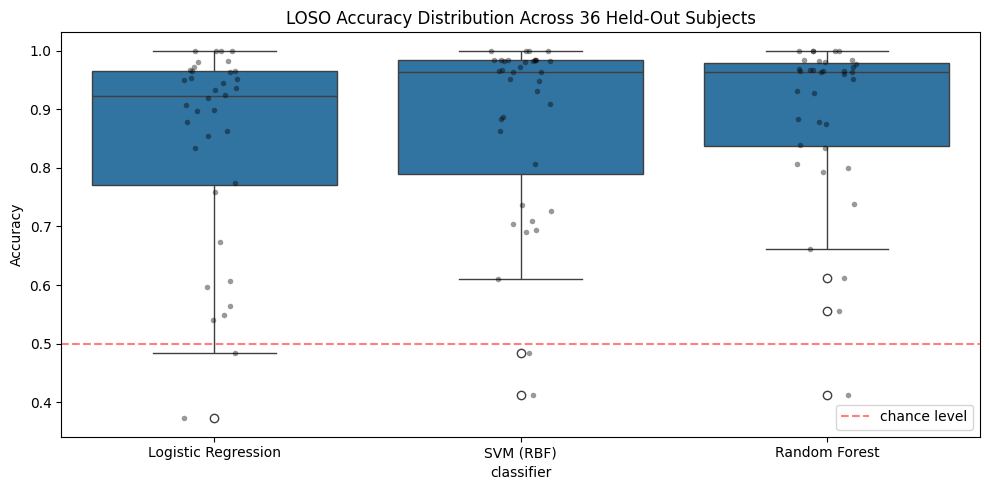


Per-subject accuracy (best classifier), sorted - useful for spotting outlier subjects:


,subject,accuracy,n_test_segments
14,4,0.411765,51
35,11,0.555556,54
8,2,0.612903,62
17,5,0.661290,62
32,10,0.737705,61
29,9,0.792453,53
104,34,0.800000,55
74,24,0.806452,62
71,23,0.833333,60
56,18,0.838710,62


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.boxplot(data=loso_df, x="classifier", y="accuracy")
sns.stripplot(data=loso_df, x="classifier", y="accuracy", color="black", alpha=0.4, size=4)
plt.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="chance level")
plt.title("LOSO Accuracy Distribution Across 36 Held-Out Subjects")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

print("\nPer-subject accuracy (best classifier), sorted - useful for spotting outlier subjects:")
best_clf = summary.index[0]
display(
    loso_df[loso_df["classifier"] == best_clf]
    .sort_values("accuracy")
    [["subject", "accuracy", "n_test_segments"]]
)


### Reading these numbers

Compare `summary` above (LOSO, 36 folds) against the single-split accuracy
from Stage 4/Ablation Study 1. If baseline normalization helped, LOSO mean
accuracy should sit noticeably above the pre-normalization single-split
number (~0.68-0.74). If you want to isolate normalization's effect
precisely, rerun this LOSO cell using `X_features_raw` instead of
`X_features` and diff the two `summary` tables.

If LOSO mean is still well under 90%, that's the honest subject-independent
ceiling for this feature set + these classifiers on this 36-subject
dataset - at that point the next lever is richer features (connectivity /
asymmetry) or an end-to-end deep model, not more classical-ML tuning.